1. Normalized + windowed time-series dataset
1.1. Conceptual setup (for a paper)

You have, for each experiment 
e∈{1,…,E}:

Physical model output:

𝑇𝑐(𝑒)(𝑡𝑖)𝑖=1,…,𝑛

Measured spindle current:

𝐼𝑞(𝑒)(𝑡𝑖)Iq(e)(ti)

You want to train a neural map 
𝑁𝜃:𝑥𝑖:𝑖+𝐿−1↦𝑦𝑖:𝑖+𝐿−1

↦yi:i+L−1
where
𝑥𝑖:𝑖+𝐿−1x
is a window of modeled torque (and possibly other features),
𝑦𝑖:𝑖+𝐿−1yi:i+L−1
	​
is the corresponding window of measured current,

L is the sequence length (“window size”).
This respects temporal structure, which a simple i.i.d. regression would ignore.
1.2. Normalization

For training stability, you usually normalize features to zero mean and unit variance:

𝑇~𝑐=𝑇𝑐−𝜇𝑇
𝐼~𝑞=𝐼𝑞−𝜇𝐼𝜎𝐼

Crucially, you estimate 

 on the training set only, then apply them to validation/test data.

In [1]:
def interpolate_nan(x):
    """Interpolate NaN values in a 1D array."""
    x = x.copy()
    nans = np.isnan(x)
    
    if np.all(nans):
        raise ValueError("Array contains only NaNs — cannot interpolate.")
    
    x[nans] = np.interp(
        np.flatnonzero(nans),
        np.flatnonzero(~nans),
        x[~nans]
    )
    return x


In [2]:
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Load all measurement files ---
tool_type = 'C1030'

base = (f"../../../data/preprocessed/Mill/measurement_*_training_data.csv")
files = sorted(glob.glob(base))

all_Tc = []
all_Iq = []

for f in files:
    df = pd.read_csv(f)
    Tc = df["Tc_model"].values.astype(float)
    Iq = df["Iq_real"].values.astype(float)
    Tc_clean = interpolate_nan(Tc)
    Iq_clean = interpolate_nan(Iq)

    all_Tc.append(Tc_clean)
    all_Iq.append(Iq_clean)
## interpolate NaNs
Tc_clean = interpolate_nan(Tc)
Iq_clean = interpolate_nan(Iq)


# Concatenate all experiments (we keep separate arrays too if needed)
Tc_all = np.concatenate(all_Tc)
Iq_all = np.concatenate(all_Iq)

# --- Compute normalization on entire dataset (or better: just on training split later) ---
Tc_mean, Tc_std = Tc_all.mean(), Tc_all.std()
Iq_mean, Iq_std = Iq_all.mean(), Iq_all.std()

def normalize_Tc(x):
    return (x - Tc_mean) / Tc_std

def normalize_Iq(y):
    return (y - Iq_mean) / Iq_std

# --- Build windowed dataset ---
def build_windows(Tc_list, Iq_list, window_size=128, stride=1):
    X, Y = [], []
    for Tc, Iq in zip(Tc_list, Iq_list):
        Tc_norm = normalize_Tc(Tc)
        Iq_norm = normalize_Iq(Iq)
        n = len(Tc)
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            X.append(Tc_norm[start:end])   # (L,)
            Y.append(Iq_norm[start:end])   # (L,)
    X = np.array(X)[..., None]  # shape: (num_windows, L, 1)
    Y = np.array(Y)[..., None]  # shape: (num_windows, L, 1)
    return X, Y

X, Y = build_windows(all_Tc, all_Iq, window_size=128, stride=16)

# Train/validation split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)


In [3]:
## check if Tc and Iq have NaNs
print(f'NaNs found in X_train {np.isnan(X_train).sum()}')
print(f'NaNs found in Y_train {np.isnan(Y_train).sum()}')


NaNs found in X_train 0
NaNs found in Y_train 0


## Keras baseline model

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
features = X_train.shape[2]   # 1 in our case

def build_baseline_conv_model(timesteps, features):
    inputs = layers.Input(shape=(timesteps, features))
    
    x = layers.Conv1D(filters=32, kernel_size=5, padding="same", activation="relu")(inputs)
    x = layers.Conv1D(filters=32, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.Conv1D(filters=16, kernel_size=5, padding="same", activation="relu")(x)
    
    # Final layer outputs one channel (Iq prediction)
    outputs = layers.Conv1D(filters=1, kernel_size=1, padding="same", activation="linear")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

baseline_model = build_baseline_conv_model(timesteps, features)
baseline_model.summary()

history = baseline_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=64
)


2025-11-28 07:04:34.402428: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-11-28 07:04:40.191210: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-11-28 07:04:40.202167: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-11-28 07:04:42.283308: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:927] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-11-28 07:04:42.283384: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce RTX 4050 Laptop GPU computeCapability: 8.9
coreClock: 2.13GHz coreCount: 20 deviceMemorySize: 6.00GiB deviceMemoryBandwidth: 178.84GiB/s
2025-11-28 07:04:42.283415: I tensorflow/stream_execu

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 128, 1)]          0         
_________________________________________________________________
conv1d (Conv1D)              (None, 128, 32)           192       
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 128, 32)           5152      
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 128, 16)           2576      
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 128, 1)            17        
Total params: 7,937
Trainable params: 7,937
Non-trainable params: 0
_________________________________________________________________


2025-11-28 07:04:59.015436: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-11-28 07:04:59.066353: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2918400000 Hz


Epoch 1/60


2025-11-28 07:04:59.640094: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7
2025-11-28 07:15:48.463630: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2025-11-28 07:15:51.730027: W tensorflow/core/framework/op_kernel.cc:1763] OP_REQUIRES failed at cwise_op_gpu_base.cc:89 : Internal: Failed to load in-memory CUBIN: CUDA_ERROR_NO_BINARY_FOR_GPU: no kernel image is available for execution on the device


InternalError:  Failed to load in-memory CUBIN: CUDA_ERROR_NO_BINARY_FOR_GPU: no kernel image is available for execution on the device
	 [[node Abs (defined at tmp/ipykernel_295889/1022986285.py:28) ]] [Op:__inference_train_function_833]

Function call stack:
train_function


## Keras LSTM model

In [ ]:
def build_lstm_seq2seq_model(timesteps, features, hidden_units=64):
    inputs = layers.Input(shape=(timesteps, features))

    x = layers.LSTM(hidden_units, return_sequences=True)(inputs)
    x = layers.LSTM(hidden_units, return_sequences=True)(x)
    
    # Time-distributed dense over each timestep
    outputs = layers.TimeDistributed(layers.Dense(1))(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

lstm_model = build_lstm_seq2seq_model(timesteps, features, hidden_units=128)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=32
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 128, 1)         │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - loss: 0.9120 - mae: 0.7878 - val_loss: 0.8813 - val_mae: 0.7749
Epoch 2/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 0.8817 - mae: 0.7709 - val_loss: 0.8678 - val_mae: 0.7624
Epoch 3/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 0.8527 - mae: 0.7522 - val_loss: 0.8313 - val_mae: 0.7387
Epoch 4/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - loss: 0.8362 - mae: 0.7395 - val_loss: 0.8285 - val_mae: 0.7380
Epoch 5/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 0.8198 - mae: 0.7297 - val_loss: 0.8096 - val_mae: 0.7237
Epoch 6/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 0.8022 - mae: 0.7184 - val_loss: 0.8055 - val_mae: 0.7216
Epoch 7/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 0.7995 - mae: 0.7187 - val_loss: 0.7924 - val_mae: 0.7159
Epoch 8/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 0.7819 - mae: 0.7076 - val_loss: 0.7561 - val_mae: 0.6896
Epoch 9/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12,5))
    
    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title("Loss During Training", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    # --- MAE ---
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
    plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    plt.title("MAE During Training", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Mean Absolute Error", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


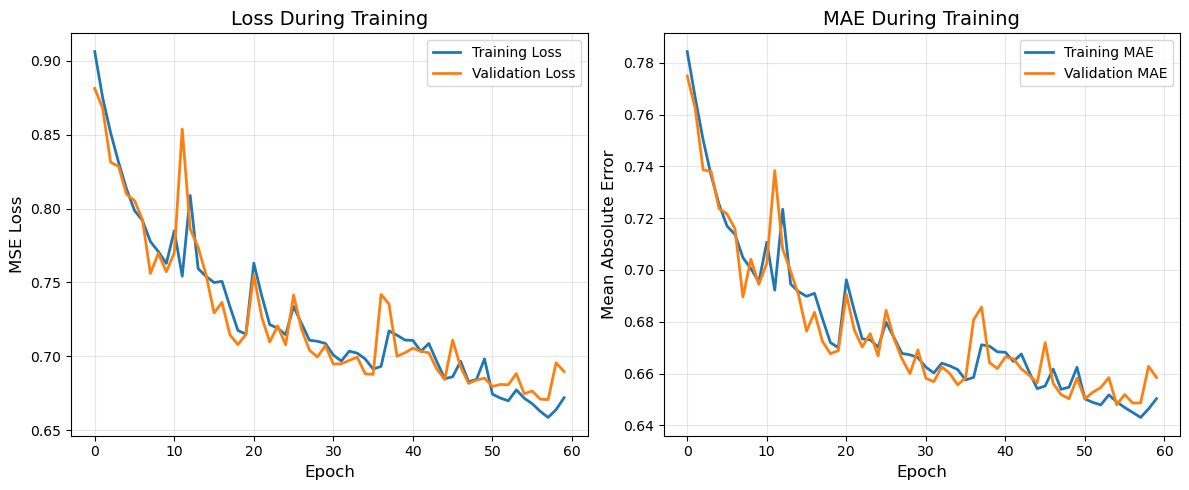

In [ ]:
plot_training_history(history_lstm)

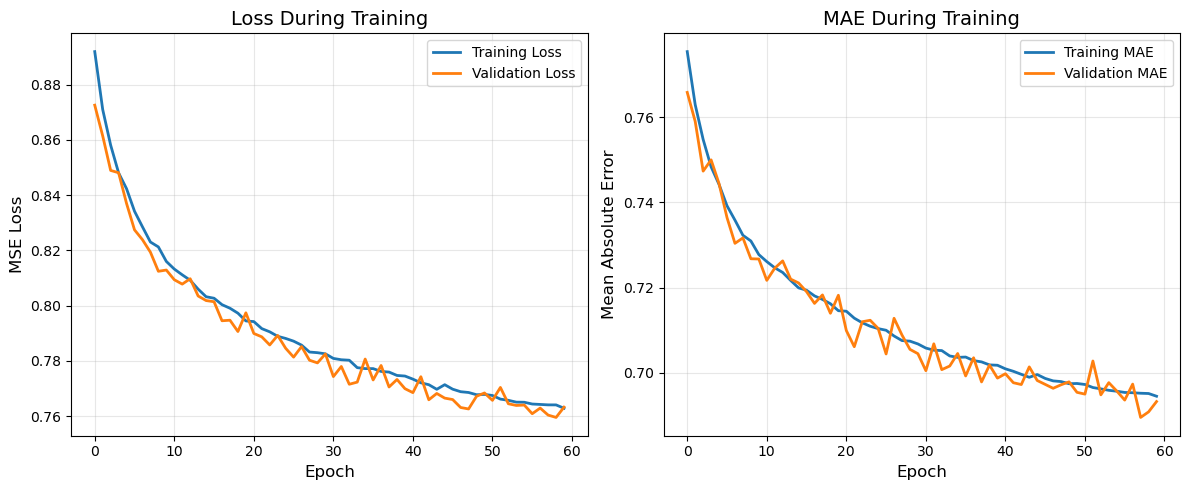

In [ ]:
plot_training_history(history)